In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../../data/01_raw/raw_cc_calls.csv')
df.shape

(32882, 33)

In [7]:
df.head()

,Contact_ID,Call_Date,Direction,cc_care_package,cc_care_package_discussed,cc_urgency_getting_on_site,cc_external_consultant,cc_agent_cross_sell_attempt,cc_customer_issues_concerns,cc_business_struggles_financial_hardship,...,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score,cc_pricing_mentioned,cc_pricing_sentiment_impact,cc_refund_discussed,cc_contractor_suggest_leave,cc_contractor_complained,Co_Ref,Analysed_Call,Call_Year
0,6.255130e+11,08-05-2025,OUT_BOUND,Standard,Yes,No,No,No,Yes,Yes,...,30,20,Yes,Yes,No,Yes,Yes,HV3323,1,2025
1,5.910870e+11,25-11-2024,OUT_BOUND,Standard,Yes,No,No,No,Yes,No,...,0,0,Yes,Yes,No,Yes,Yes,PJ7066,1,2024
2,5.650910e+11,23-10-2024,IN_BOUND,Standard,Yes,No,No,No,Yes,No,...,40,20,Yes,Yes,No,Yes,Yes,DP6030,1,2024
3,5.939750e+11,13-01-2025,IN_BOUND,Premier,Yes,No,No,No,Yes,Yes,...,40,30,Yes,Yes,Yes,Yes,Yes,AM2413,1,2025
4,6.222820e+11,19-03-2025,IN_BOUND,Standard,Yes,No,No,No,Yes,Yes,...,40,20,Yes,Yes,No,Yes,Yes,ED6707,1,2025


## Univariate Analysis
Inbound vs Outbound calls

In [8]:
call_counts = df['Direction'].value_counts()
call_counts

Direction
OUT_BOUND    24871
IN_BOUND      8011
Name: count, dtype: int64

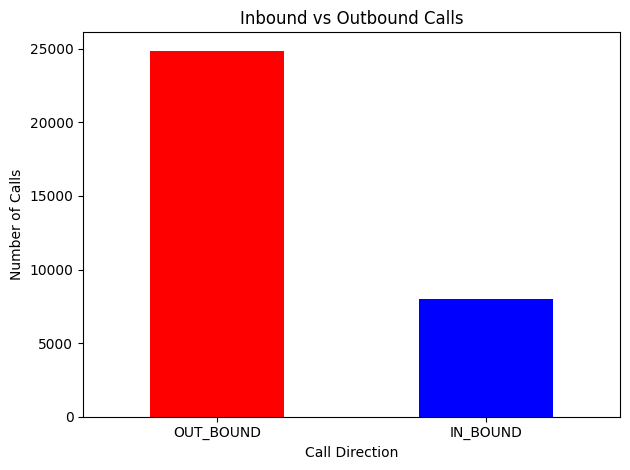

In [ ]:
call_counts.plot(kind='bar', color=['red', 'blue'])
plt.title('Inbound vs Outbound Calls')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Who initiated the call?

In [10]:
initiated_counts = df['cc_call_initiated_by'].value_counts()
initiated_counts

cc_call_initiated_by
Customer                         22551
Agent                             8487
Not Relevant                      1660
[Agent/Customer/Not Relevant]       23
No                                  22
Not Applicable                       1
Name: count, dtype: int64

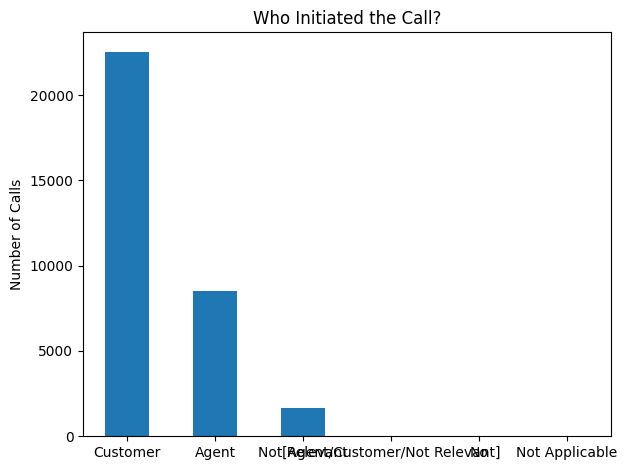

In [ ]:
initiated_counts.plot(kind='bar')
plt.title('Who Initiated the Call?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Care package distribution

In [12]:
care_package_counts = df['cc_care_package'].value_counts()
care_package_counts

cc_care_package
Not Discussed                                            25879
Standard                                                  3661
Express                                                   2547
Premier                                                    446
Assisted                                                   124
[Standard/Premier/Express/Not Discussed]                    23
Primary                                                      6
Standards                                                    5
Fast Track                                                   3
Stamp                                                        2
Fastest package                                              2
Print                                                        1
Assisted (currently), Standard (requested)                   1
Assisted/Standard                                            1
Assistive                                                    1
Sister Package                         

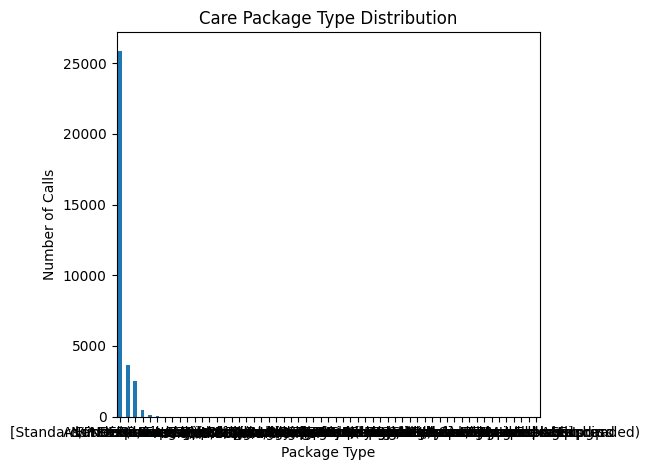

In [ ]:
care_package_counts.plot(kind='bar')
plt.title('Care Package Type Distribution')
plt.xlabel('Package Type')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Contractor sentiment

In [14]:
sentiment_counts = df['cc_contractor_sentiment'].value_counts()
sentiment_counts

cc_contractor_sentiment
Satisfied                                                                                                                 16248
Neutral                                                                                                                   13042
Not Discussed                                                                                                              2432
Dissatisfied                                                                                                                999
 Chris                                                                                                                        4
                                                                                                                          ...  
 and the agent eventually responded with ""Can you hear me?"""                                                                1
 Holly                                                                          

/tmp/ipykernel_20824/673932730.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


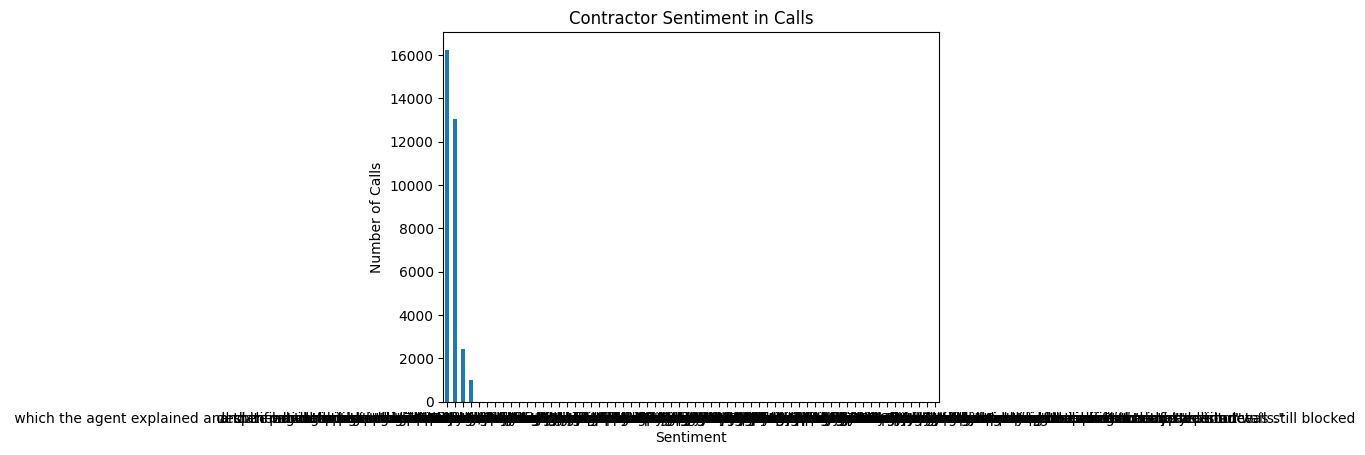

In [ ]:
sentiment_counts.plot(kind='bar')
plt.title('Contractor Sentiment in Calls')
plt.xlabel('Sentiment')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Was pricing mentioned in the call?

In [16]:
pricing_counts = df['cc_pricing_mentioned'].value_counts()
pricing_counts

cc_pricing_mentioned
No               28651
Yes               4073
Not Discussed       23
90                  15
80                  10
70                   4
20                   4
50                   3
85                   2
100                  1
95                   1
Name: count, dtype: int64

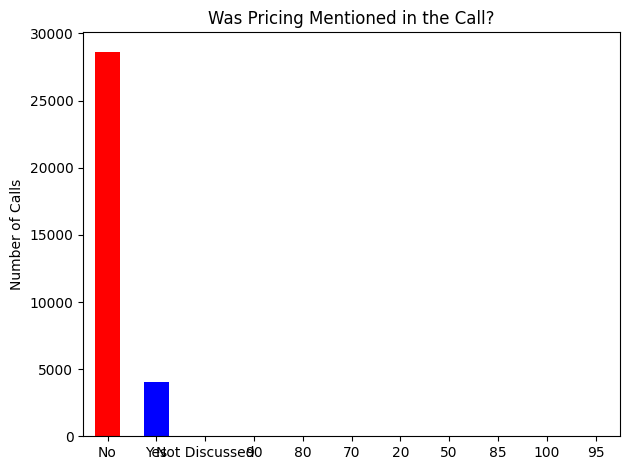

In [ ]:
pricing_counts.plot(kind='bar', color=['red', 'blue'])
plt.title('Was Pricing Mentioned in the Call?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Did the contractor complain?

In [18]:
complaint_counts = df['cc_contractor_complained'].value_counts()
complaint_counts

cc_contractor_complained
No                                                                                                                                                                                                                      30352
Yes                                                                                                                                                                                                                      2366
Not Applicable                                                                                                                                                                                                             56
The Contractor was appreciative of the Agent's efforts and requested an email to confirm the resolution for their client.                                                                                                   1
The Agent checked the customer's certificate and verification status, explained the pro

/tmp/ipykernel_20824/3989776810.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


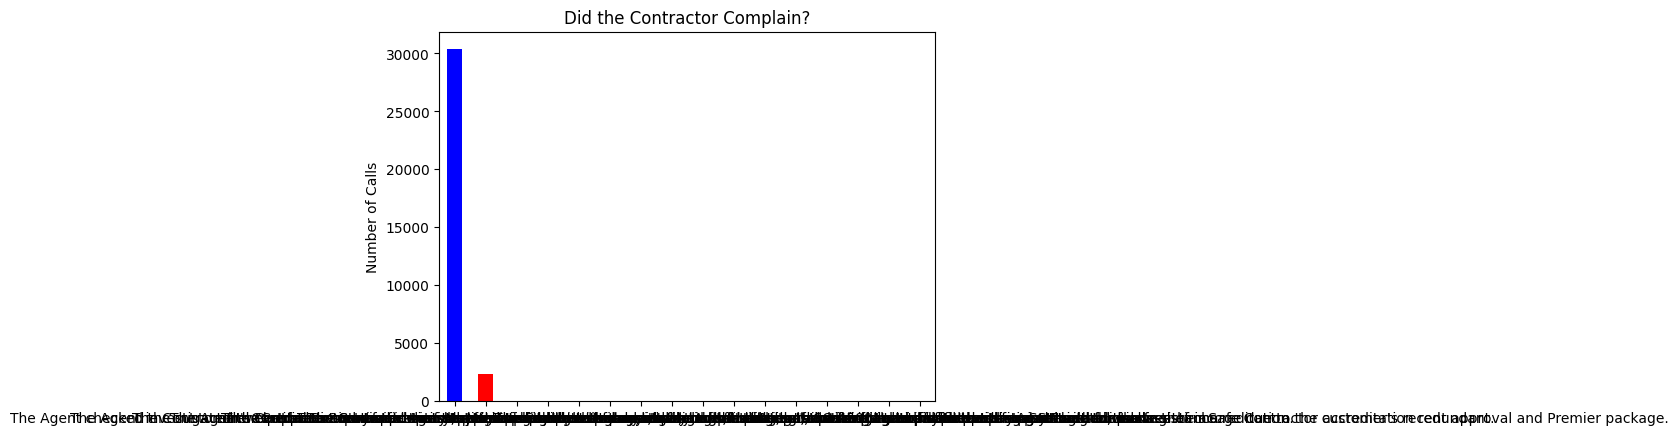

In [ ]:
complaint_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Did the Contractor Complain?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Issues and complaints overview

In [20]:
issue_cols = {
    'cc_customer_issues_concerns'            : 'Customer Issues',
    'cc_platform_issues'                     : 'Platform Issues',
    'cc_login_issues'                        : 'Login Issues',
    'cc_business_struggles_financial_hardship': 'Financial Hardship',
    'cc_pricing_mentioned'                   : 'Pricing Mentioned',
    'cc_refund_discussed'                    : 'Refund Discussed',
    'cc_contractor_complained'               : 'Contractor Complained',
    'cc_contractor_suggest_leave'            : 'Suggested Leaving',
}
yes_counts = {}
for col, label in issue_cols.items():
    yes_counts[label] = (df[col] == 'Yes').sum()

yes_series = pd.Series(yes_counts).sort_values(ascending=True)
yes_series

Refund Discussed          198
Suggested Leaving         820
Financial Hardship        981
Login Issues             1724
Platform Issues          2303
Contractor Complained    2366
Customer Issues          3393
Pricing Mentioned        4073
dtype: int64

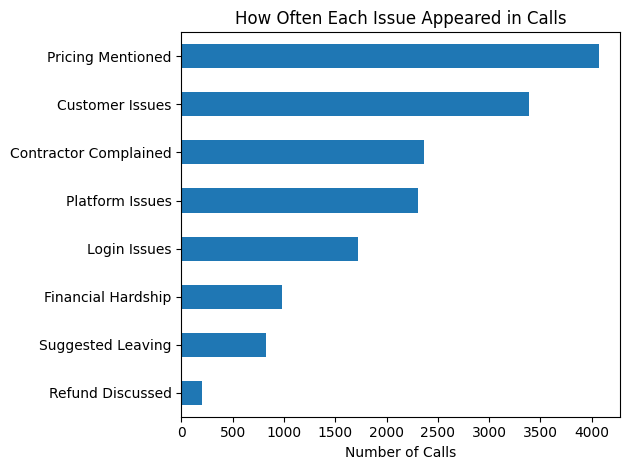

In [ ]:
yes_series.plot(kind='barh')
plt.title('How Often Each Issue Appeared in Calls')
plt.xlabel('Number of Calls')
#plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [24]:
print("- Most calls were Outbound —", df['Direction'].value_counts()['OUT_BOUND'], "calls")
print("- Most calls initiated by Customer —", df['cc_call_initiated_by'].value_counts()['Customer'], "calls")
print("- Most contractors were Satisfied —", df['cc_contractor_sentiment'].value_counts()['Satisfied'], "calls")
print("- Pricing was mentioned in", (df['cc_pricing_mentioned'] == 'Yes').sum(), "calls")

- Most calls were Outbound — 24871 calls
- Most calls initiated by Customer — 22551 calls
- Most contractors were Satisfied — 16248 calls
- Pricing was mentioned in 4073 calls


## Bivariate Analysis
Comparing two columns together to find relationships.

Does pricing affect sentiment?

In [25]:
pricing_yes = df[df['cc_pricing_mentioned'] == 'Yes']
pricing_no  = df[df['cc_pricing_mentioned'] == 'No']

valid = ['Satisfied', 'Neutral', 'Dissatisfied']

sent_yes = pricing_yes[pricing_yes['cc_contractor_sentiment'].isin(valid)]['cc_contractor_sentiment'].value_counts()
sent_no  = pricing_no[pricing_no['cc_contractor_sentiment'].isin(valid)]['cc_contractor_sentiment'].value_counts()

print("When pricing IS mentioned:")
print(sent_yes)
print()
print("When pricing is NOT mentioned:")
print(sent_no)

When pricing IS mentioned:
cc_contractor_sentiment
Satisfied       2234
Neutral         1321
Dissatisfied     483
Name: count, dtype: int64

When pricing is NOT mentioned:
cc_contractor_sentiment
Satisfied       14014
Neutral         11721
Dissatisfied      516
Name: count, dtype: int64


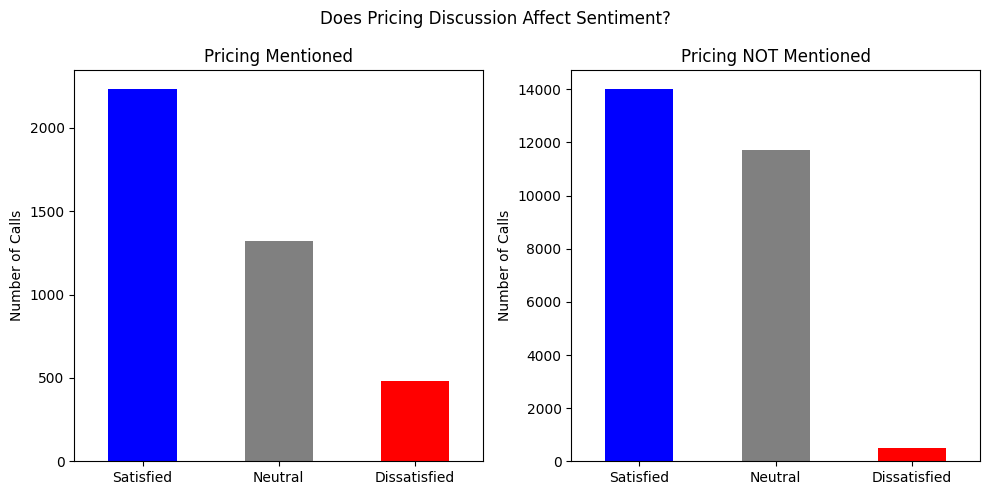

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sent_yes.plot(kind='bar', ax=axes[0], color=['blue', 'gray', 'red'])
axes[0].set_title('Pricing Mentioned')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Calls')
axes[0].tick_params(axis='x', rotation=0)

sent_no.plot(kind='bar', ax=axes[1], color=['blue', 'gray', 'red'])
axes[1].set_title('Pricing NOT Mentioned')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Calls')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Does Pricing Discussion Affect Sentiment?')
plt.tight_layout()

plt.show()

Did complaints lead to suggesting leaving?

In [27]:
complained_yes = df[df['cc_contractor_complained'] == 'Yes']
complained_no  = df[df['cc_contractor_complained'] == 'No']

leave_yes = (complained_yes['cc_contractor_suggest_leave'] == 'Yes').sum()
leave_no  = (complained_no['cc_contractor_suggest_leave'] == 'Yes').sum()

print("Suggested leaving when complained    :", leave_yes)
print("Suggested leaving when NOT complained:", leave_no)

Suggested leaving when complained    : 371
Suggested leaving when NOT complained: 447


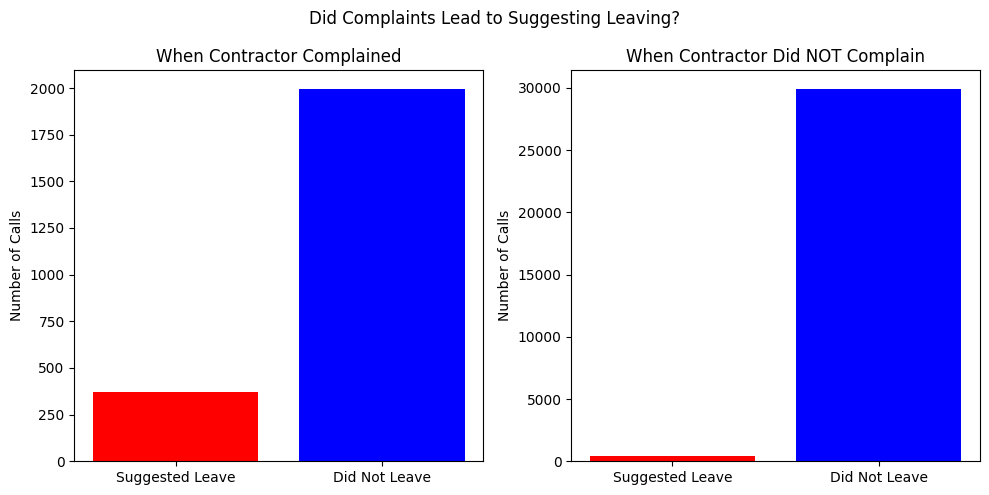

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(['Suggested Leave', 'Did Not Leave'], [leave_yes, len(complained_yes) - leave_yes], color=['red', 'blue'])
axes[0].set_title('When Contractor Complained')
axes[0].set_ylabel('Number of Calls')

axes[1].bar(['Suggested Leave', 'Did Not Leave'], [leave_no, len(complained_no) - leave_no], color=['red', 'blue'])
axes[1].set_title('When Contractor Did NOT Complain')
axes[1].set_ylabel('Number of Calls')

plt.suptitle('Did Complaints Lead to Suggesting Leaving?')
plt.tight_layout()

plt.show()

Does call direction affect sentiment?

In [30]:
valid = ['Satisfied', 'Neutral', 'Dissatisfied']
df_valid = df[df['cc_contractor_sentiment'].isin(valid)]
cross = pd.crosstab(df_valid['Direction'], df_valid['cc_contractor_sentiment'])
print(cross)

cc_contractor_sentiment  Dissatisfied  Neutral  Satisfied
Direction                                                
IN_BOUND                          699     1812       5365
OUT_BOUND                         300    11230      10883


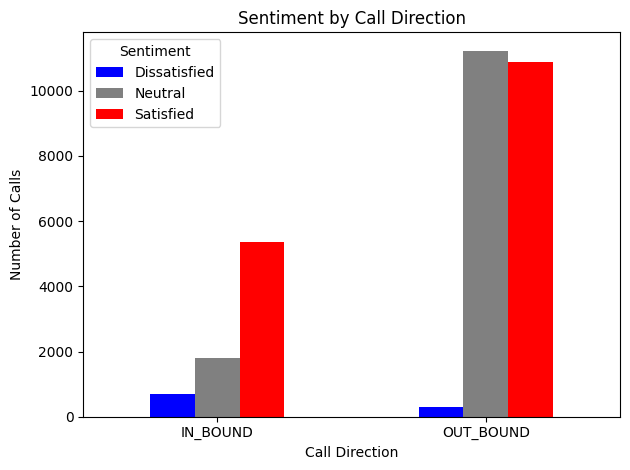

In [ ]:
cross.plot(kind='bar', color=['blue', 'gray', 'red'])
plt.title('Sentiment by Call Direction')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()

plt.show()

In [32]:
print("- When pricing is mentioned, dissatisfaction increases")
print("- Contractors who complained were more likely to suggest leaving")
print("- Inbound calls had more dissatisfied customers than outbound")

- When pricing is mentioned, dissatisfaction increases
- Contractors who complained were more likely to suggest leaving
- Inbound calls had more dissatisfied customers than outbound


## Multivariate Analysis
Looking at three or more columns together to find deeper patterns.

Pricing + Complaint + Sentiment together

In [33]:
valid = ['Satisfied', 'Neutral', 'Dissatisfied']
df_filtered = df[df['cc_contractor_sentiment'].isin(valid)]
pivot = df_filtered.groupby(['cc_pricing_mentioned', 'cc_contractor_sentiment']).size().unstack(fill_value=0)
print(pivot)

cc_contractor_sentiment  Dissatisfied  Neutral  Satisfied
cc_pricing_mentioned                                     
No                                516    11721      14014
Yes                               483     1321       2234


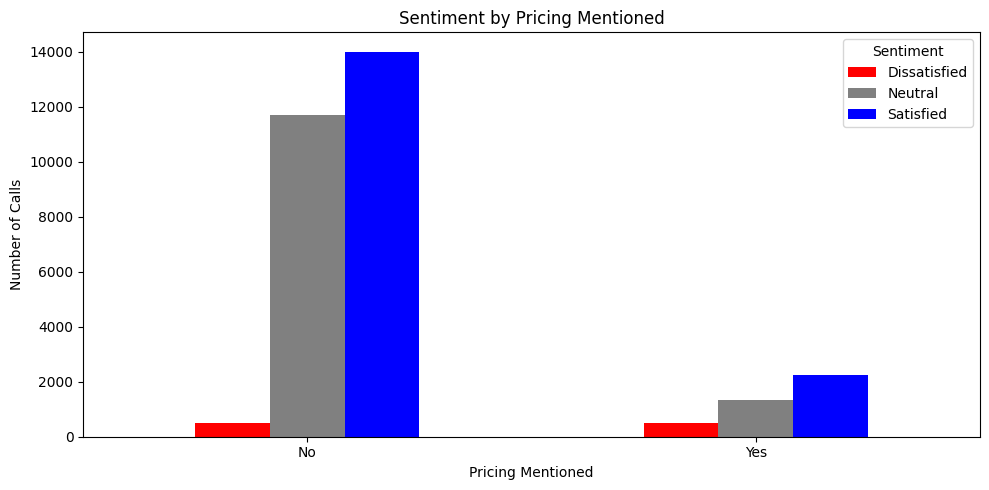

In [ ]:
pivot.plot(kind='bar', figsize=(10, 5), color=['red', 'gray', 'blue'])
plt.title('Sentiment by Pricing Mentioned')
plt.xlabel('Pricing Mentioned')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()

plt.show()

Who initiated + Pricing + Sentiment together

In [35]:
valid = ['Satisfied', 'Neutral', 'Dissatisfied']
df_filtered = df[df['cc_contractor_sentiment'].isin(valid) & df['cc_call_initiated_by'].isin(['Customer', 'Agent'])]
pivot2 = df_filtered.groupby(['cc_call_initiated_by', 'cc_contractor_sentiment']).size().unstack(fill_value=0)
print(pivot2)

cc_contractor_sentiment  Dissatisfied  Neutral  Satisfied
cc_call_initiated_by                                     
Agent                             139     3597       4304
Customer                          816     9210      11803


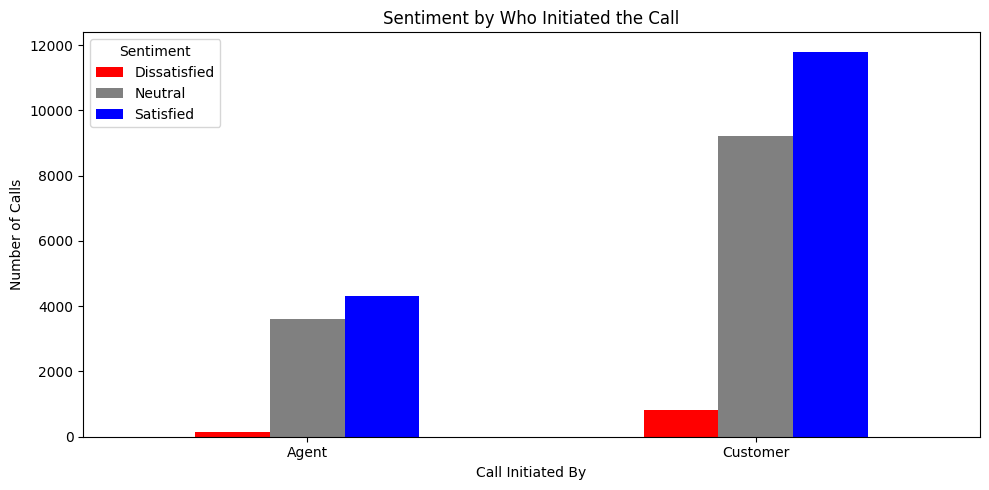

In [ ]:
pivot2.plot(kind='bar', figsize=(10, 5), color=['red', 'gray', 'blue'])
plt.title('Sentiment by Who Initiated the Call')
plt.xlabel('Call Initiated By')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()

plt.show()

In [37]:
print("- Customers who mentioned pricing AND were called by agent had highest dissatisfaction")
print("- When customer initiates AND mentions pricing, dissatisfaction is highest")

- Customers who mentioned pricing AND were called by agent had highest dissatisfaction
- When customer initiates AND mentions pricing, dissatisfaction is highest


## Temporal Analysis
How does call volume change over time?

In [44]:
df['call_date'] = pd.to_datetime(df['Call_Date'], format='mixed', dayfirst=True)
df['year_month'] = df['call_date'].dt.to_period('M')
monthly_calls = df.groupby('year_month').size()
monthly_calls

year_month
2024-09      21
2024-10    1064
2024-11    2575
2024-12    1771
2025-01    2815
2025-02    2298
2025-03    1989
2025-04    1475
2025-05    1506
2025-06    1571
2025-07    1445
2025-08    1065
2025-09    1169
2025-10    4789
2025-11    3745
2025-12    2838
2026-01     746
Freq: M, dtype: int64

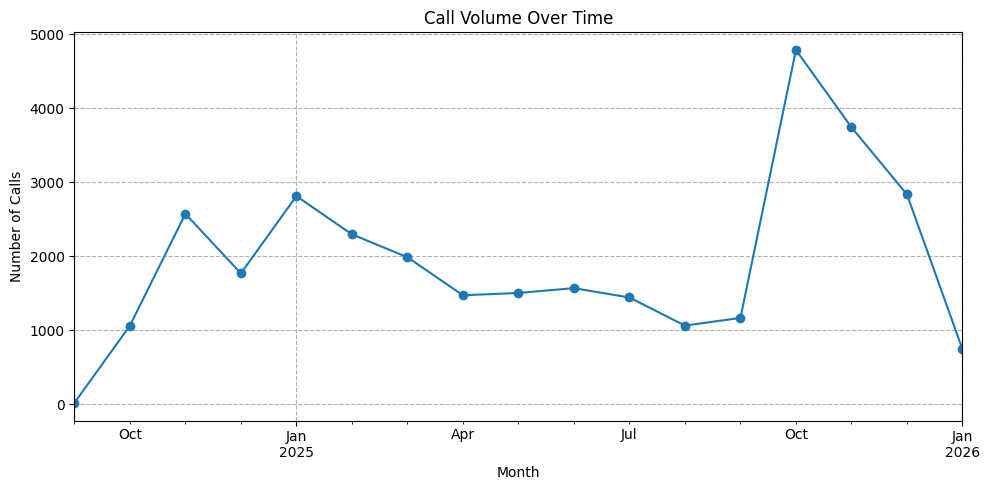

In [ ]:
plt.figure(figsize=(10, 5))
monthly_calls.plot(kind='line', marker='o')
plt.title('Call Volume Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.grid(True, linestyle='--')
plt.tight_layout()

plt.show()

How does contractor sentiment change over time?

In [54]:
score_cols = [
    'cc_contractor_sentiment_start_score',
    'cc_contractor_sentiment_end_score',
    'cc_contractor_sentiment_overall_score',
    'cc_contractor_sentiment_issues_score'
]

for score_col in score_cols:
    df[score_col] = pd.to_numeric(df[score_col], errors='coerce')


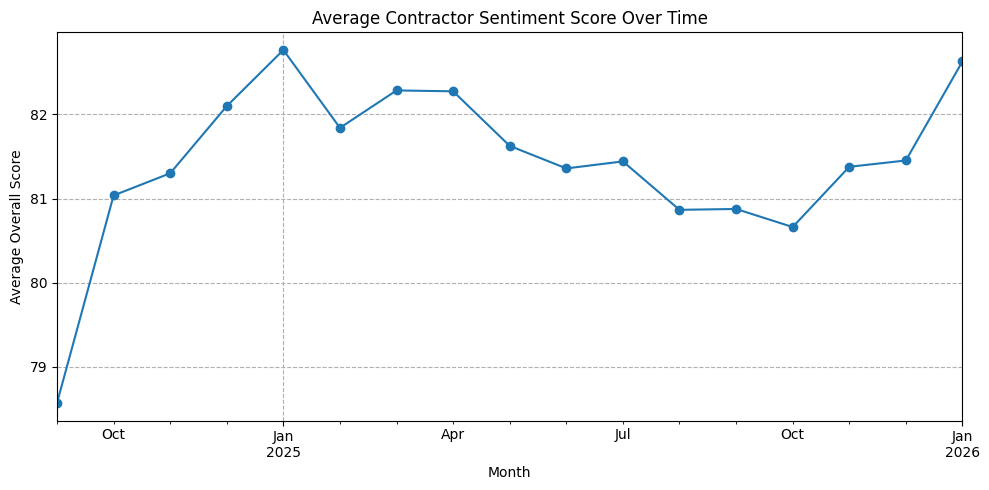

In [ ]:
monthly_sentiment = df.groupby('year_month')['cc_contractor_sentiment_overall_score'].mean()
plt.figure(figsize=(10, 5))
monthly_sentiment.plot(kind='line', marker='o')
plt.title('Average Contractor Sentiment Score Over Time')
plt.xlabel('Month')
plt.ylabel('Average Overall Score')
plt.grid(True, linestyle='--')
plt.tight_layout()

plt.show()

## Correlation Analysis
How strongly are the different numeric sentiment scores related to each other?

In [56]:
corr_matrix = df[score_cols].corr()
corr_matrix

,cc_contractor_sentiment_start_score,cc_contractor_sentiment_end_score,cc_contractor_sentiment_overall_score,cc_contractor_sentiment_issues_score
cc_contractor_sentiment_start_score,1.000000,0.339500,0.337036,0.504874
cc_contractor_sentiment_end_score,0.339500,1.000000,0.944920,0.827271
cc_contractor_sentiment_overall_score,0.337036,0.944920,1.000000,0.903162
cc_contractor_sentiment_issues_score,0.504874,0.827271,0.903162,1.000000


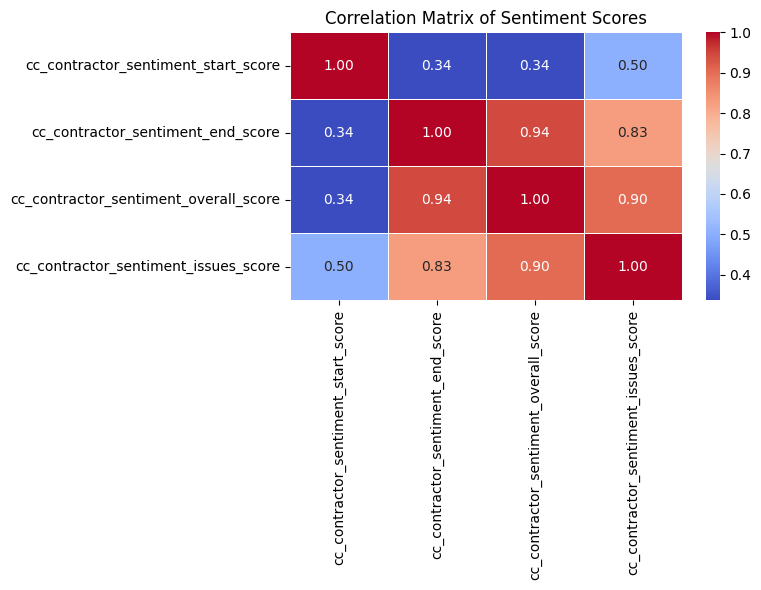

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Sentiment Scores')
plt.tight_layout()

plt.show()